# Mô hình dự báo giá cổ phiếu kết hợp (Hybrid Model: XGBoost + GARCH)

Mô hình này kết hợp khả năng dự báo giá trị trung bình (mean) mạnh mẽ của **XGBoost** với khả năng dự báo biến động (volatility) của **GARCH**. Mục tiêu là không chỉ đưa ra một mức giá dự báo cụ thể, mà còn xác định được khoảng rủi ro (dải Bollinger Bands dự báo) cho phiên giao dịch tiếp theo.

## 1. Khởi tạo và Đọc dữ liệu
Trong bước này, chúng ta sẽ nạp các thư viện cần thiết cho việc xử lý dữ liệu (Pandas, Numpy), học máy (XGBoost, Scikit-learn) và thống kê tài chính (Arch). Dữ liệu lịch sử giá cổ phiếu sẽ được tải lên, định dạng lại index dưới dạng chuỗi thời gian (datetime) và xử lý nhanh các giá trị bị lỗi (ép kiểu numeric và loại bỏ NaN).

In [8]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from arch import arch_model
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import t

# Đọc dữ liệu
from load_data import load_vcb_data
df = load_vcb_data()
df.sort_index(inplace=True)

# Ép kiểu dữ liệu và xử lý giá trị lỗi
features_to_fix = ['Close', 'RSI', 'Volume']
for col in features_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df.dropna(inplace=True)

# Hiển thị vài dòng đầu để kiểm tra
display(df.head())

d:\AdyFinal\database.py:142: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Close,High,Low,Open,Volume,RSI,MA10,MA20,MA50,MACD
Date,,,,,,,,,,
2020-03-11,49518.656250,51705.193551,47846.598091,51705.193551,2721848,24.586404,52637.687109,54878.888477,56864.136719,-484.688449
2020-03-12,46110.226562,46946.253695,46110.226562,46303.153862,2384607,18.542280,51782.364844,54309.745313,56626.189844,-720.080689
2020-03-13,45660.054688,46946.250479,42894.724462,42894.724462,2802561,17.915833,50946.335547,53721.309375,56371.522422,-845.157115
2020-03-16,43151.968750,45660.057712,42766.110366,45660.057712,1540937,14.896252,49962.392969,53007.469141,56078.269063,-1023.937998
2020-03-17,43409.207031,43409.207031,40901.118252,40901.118252,2056377,16.451593,49042.760547,52303.275000,55821.029297,-1048.197511


## 2. Trích xuất đặc trưng (Feature Engineering)
Dữ liệu giá thô không đủ để máy học nhận diện xu hướng. Chúng ta cần chế biến chúng thành các tín hiệu (signals) mang tính dự báo:
*   **Động lượng (Momentum):** Tỷ suất sinh lời của 1, 3 và 5 phiên gần nhất.
*   **Xu hướng (Trend):** Các đường trung bình động (SMA_5, SMA_20) và trung bình khối lượng.
*   **Biến động (Volatility):** Độ lệch chuẩn của tỷ suất sinh lời trong quá khứ.
*   **Độ trễ (Lags):** Giá và khối lượng của các phiên trước đó để mô hình học được tính tự tương quan (autocorrelation).

Cuối cùng, biến mục tiêu (`Target_Return`) được xác định là tỷ suất sinh lời của **phiên giao dịch tiếp theo** (`shift(-1)`).

In [9]:
# 1. Tính toán Return
df['Return_1d'] = df['Close'].pct_change() * 100
df['Return_3d'] = df['Close'].pct_change(3) * 100
df['Return_5d'] = df['Close'].pct_change(5) * 100

# 2. Moving Averages
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()
df['Volume_MA_5'] = df['Volume'].rolling(5).mean()
df['Volume_Change'] = df['Volume'].pct_change()

# 3. Volatility
df['Hist_Volatility_5'] = df['Return_1d'].rolling(5).std()
df['Hist_Volatility_20'] = df['Return_1d'].rolling(20).std()

# 4. Lags
df['Close_lag_1'] = df['Close'].shift(1)
df['Close_lag_3'] = df['Close'].shift(3)
df['Volume_lag_1'] = df['Volume'].shift(1)

# 5. Target Variable
df['Target_Return'] = df['Return_1d'].shift(-1)

# Làm sạch dữ liệu sau khi tạo features
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

features = [
    'Close', 'RSI', 'Volume', 'Return_1d', 'Return_3d', 'Return_5d',
    'SMA_5', 'SMA_20', 'Volume_MA_5', 'Volume_Change', 
    'Hist_Volatility_5', 'Hist_Volatility_20', 'Close_lag_1', 'Close_lag_3', 'Volume_lag_1'
]

X = df[features]
y = df['Target_Return']

print(f"[INFO] Kích thước tập dữ liệu sau khi tạo features: X={X.shape}, y={y.shape}")

[INFO] Kích thước tập dữ liệu sau khi tạo features: X=(1526, 15), y=(1526,)


## 3. Huấn luyện mô hình gốc (XGBoost - Mean Model)
Đối với dữ liệu tài chính, việc chia tập Train/Test ngẫu nhiên sẽ gây ra lỗi rò rỉ dữ liệu (data leakage). Ở đây, chúng ta áp dụng **TimeSeriesSplit** để tôn trọng thứ tự thời gian.

**Quy trình 2 bước:**
1.  **Tạo phần dư (OOF Residuals):** Huấn luyện mô hình trên các nếp gấp (folds) thời gian để lấy ra các phần dư (sai số thực tế trừ dự báo). Các phần dư này chính là đầu vào để mô hình GARCH học cấu trúc biến động.
2.  **Huấn luyện Main Model:** Huấn luyện mô hình XGBoost tổng thể trên toàn bộ tập Train có áp dụng cơ chế Early Stopping để chống over-fitting.

In [10]:
# =====================================================================
# 1. Chia tập data
split_idx = int(len(X) * 0.8)
X_train_full, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_full, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

val_split_idx = int(len(X_train_full) * 0.8)
X_train, X_val = X_train_full.iloc[:val_split_idx], X_train_full.iloc[val_split_idx:]
y_train, y_val = y_train_full.iloc[:val_split_idx], y_train_full.iloc[val_split_idx:]

# 2. Tạo Out-of-Fold (OOF) Residuals
print("[INFO] Đang tạo Out-of-Fold Residuals bằng TimeSeriesSplit...")
tscv = TimeSeriesSplit(n_splits=5)
oof_pred = pd.Series(index=X_train_full.index, dtype=float)

for train_idx, val_idx in tscv.split(X_train_full):
    X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
    X_va = X_train_full.iloc[val_idx]
    
    fold_model = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=3,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, objective='reg:squarederror', random_state=42
    )
    fold_model.fit(X_tr, y_tr, verbose=False)
    oof_pred.iloc[val_idx] = fold_model.predict(X_va)

valid_oof_idx = oof_pred.dropna().index
residuals_train = y_train_full.loc[valid_oof_idx] - oof_pred.dropna()

# 3. Huấn luyện XGBoost chính
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.01, max_depth=3, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    objective='reg:squarederror', random_state=42, early_stopping_rounds=50
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"[INFO] XGBoost Training kết thúc. Best Iteration: {xgb_model.best_iteration}")
joblib.dump(xgb_model, '../models/vcb_xgb_model.pkl')
print("[SUCCESS] Đã xuất file mô hình vào thư mục models thành công!")

[INFO] Đang tạo Out-of-Fold Residuals bằng TimeSeriesSplit...
[INFO] XGBoost Training kết thúc. Best Iteration: 210
[SUCCESS] Đã xuất file mô hình vào thư mục models thành công!


## 4. Dự báo biến động (GARCH - Variance Model)
XGBoost chỉ dự báo được một điểm giá duy nhất. Để biết "giá có thể dao động trong khoảng nào", chúng ta sử dụng mô hình GARCH(1,1).

Mô hình học từ chuỗi phần dư (residuals) do XGBoost để lại. Chúng ta sử dụng **phân phối Student-t** thay vì phân phối chuẩn (Normal) để mô phỏng tốt hơn hiện tượng "đuôi mập" (fat tails) - những cú sốc lớn thường xuyên xảy ra trên thị trường chứng khoán. Việc dự báo được thực hiện theo phương pháp **cuốn chiếu (rolling)** và cập nhật liên tục để bám sát mức độ biến động mới nhất của thị trường.

In [11]:
# [Cell 4] ============================================================
# VOLATILITY MODELING (GARCH)
# =====================================================================
test_volatility = []
history_resids = list(residuals_train.values)
refit_every = 20   
window_size = 500  

# Khởi tạo mô hình GARCH ban đầu
am = arch_model(history_resids[-window_size:], vol='Garch', p=1, q=1, dist='t')
current_res = am.fit(disp='off')

print("[INFO] Đang chạy dự báo biến động GARCH cuốn chiếu...")
for i in range(len(X_test)):
    # Refit lại mô hình định kỳ
    if i > 0 and i % refit_every == 0:
        recent_history = history_resids[-window_size:]
        am = arch_model(recent_history, vol='Garch', p=1, q=1, dist='t')
        current_res = am.fit(disp='off')
        
    # Dự báo variance cho bước tiếp theo
    fc = current_res.forecast(horizon=1, reindex=False)
    pred_vol = np.sqrt(fc.variance.values[-1, -1])
    test_volatility.append(pred_vol)
    
    # Cập nhật residuals mới bằng dự báo của XGBoost
    pred_ret = xgb_model.predict(X_test.iloc[[i]])[0]
    actual_ret = y_test.iloc[i]
    true_resid = actual_ret - pred_ret
    history_resids.append(true_resid)

test_volatility = np.array(test_volatility)
nu_df = current_res.params.get('df', 5.0)
critical_value = t.ppf(0.975, df=nu_df)

print(f"[INFO] Tính toán GARCH hoàn tất. Critical Value (Student-t): {critical_value:.4f}")

[INFO] Đang chạy dự báo biến động GARCH cuốn chiếu...
[INFO] Tính toán GARCH hoàn tất. Critical Value (Student-t): 2.5706


## 5. Tổng hợp kết quả và Xây dựng Dải Bollinger Dự báo
Bước cuối cùng là ghép nối 2 mảnh ghép lại với nhau:
1.  **Dự báo điểm (Point Forecast):** Sử dụng lợi nhuận dự báo từ XGBoost để tính ra mức giá đóng cửa dự kiến (`Predicted_Next_Close`).
2.  **Khoảng tin cậy (Confidence Interval):** Kết hợp giá trị dự báo, mức biến động từ GARCH và giá trị tới hạn (critical value) của phân phối Student-t để tạo ra dải biên trên (`Bollinger_Upper`) và biên dưới (`Bollinger_Lower`).

Bảng kết quả cuối cùng sẽ hiển thị chi tiết so sánh giữa thực tế và dự báo, sẵn sàng để xuất ra CSV phục vụ việc kiểm định chiến lược (backtest) hoặc giao dịch tự động.

In [17]:
# [Cell 5] ============================================================
# RESULT VISUALIZATION & EXPORT
# =====================================================================
# 1. Khôi phục giá tuyệt đối
pred_test_returns = xgb_model.predict(X_test)
actual_close_base = df['Close'].loc[X_test.index] 
actual_next_close = df['Close'].shift(-1).loc[X_test.index] 

predicted_next_close = actual_close_base * (1 + pred_test_returns / 100)
bollinger_upper_pred = actual_close_base * (1 + (pred_test_returns + critical_value * test_volatility) / 100)
bollinger_lower_pred = actual_close_base * (1 + (pred_test_returns - critical_value * test_volatility) / 100)

# 2. Đóng gói kết quả
output_df = pd.DataFrame({
    'Actual_Next_Close': actual_next_close,
    'Predicted_Next_Close': predicted_next_close,
    'Bollinger_Upper': bollinger_upper_pred,
    'Bollinger_Lower': bollinger_lower_pred,
    'Actual_Return': y_test,
    'Pred_Return': pred_test_returns
}, index=X_test.index)

# Loại bỏ phần tử cuối do chưa có tương lai để đối chứng
output_df.dropna(subset=['Actual_Next_Close'], inplace=True)

# 3. Xuất file
output_df.to_csv('../data/hybrid_predictions_output.csv')
with open('../configs/garch_config.txt', 'w') as f:
    f.write(f"{critical_value}")
print("[SUCCESS] Đã xuất file vào thư mục data và configs thành công!")

# 4. Hiển thị bảng kết quả tương tác (sử dụng styling của Pandas)
display(output_df.style.format("{:.2f}").background_gradient(cmap='viridis', subset=['Pred_Return']))

[SUCCESS] Đã xuất file vào thư mục data và configs thành công!


,Actual_Next_Close,Predicted_Next_Close,Bollinger_Upper,Bollinger_Lower,Actual_Return,Pred_Return
Date,,,,,,
2025-04-25 00:00:00,56613.99,56803.91,60069.81,53538.02,0.00,0.34
2025-04-28 00:00:00,56417.07,56759.71,60025.60,53493.82,-0.35,0.26
2025-04-29 00:00:00,56417.07,56603.97,59858.51,53349.44,0.00,0.33
2025-04-30 00:00:00,56121.70,56583.01,59837.54,53328.47,0.00,0.29
2025-05-07 00:00:00,56121.70,56322.16,59559.66,53084.67,0.00,0.36
2025-05-08 00:00:00,56220.15,56296.87,59534.37,53059.38,0.18,0.31
2025-05-09 00:00:00,56220.15,56332.83,59576.01,53089.66,0.00,0.20
2025-05-12 00:00:00,55924.78,56359.63,59602.81,53116.46,-0.88,0.25
2025-05-14 00:00:00,57795.50,55972.46,59198.60,52746.33,3.35,0.09


<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_3872\3379510865.py:65: SyntaxWarning: invalid escape sequence '\s'
  label=f'Khoảng Tin Cậy Phương Sai Điều Kiện (GARCH Student-t {critical_value:.2f}$\sigma$)'



================== BÁO CÁO KIỂM ĐỊNH MÔ HÌNH TOÀN DIỆN ==================
MAE  (Sai số tuyệt đối trung bình giá Close)  : 642.82 VND
RMSE (Sai số căn bậc hai trung bình giá Close): 1,043.58 VND
MAPE (Sai số phần trăm trung bình giá Close)  : 1.04%
-------------------------------------------------------------------------
MÔ HÌNH: Directional Accuracy (Đoán trúng hướng) : 51.24%
BASELINE 1: Always Up Accuracy (Luôn đoán TĂNG) : 49.17%
BASELINE 2: Always Down Accuracy (Luôn đoán GIẢM): 50.83%
-------------------------------------------------------------------------
ĐỘ CHUẨN RỦI RO: GARCH 95% CI Coverage (Độ phủ dải): 95.74%



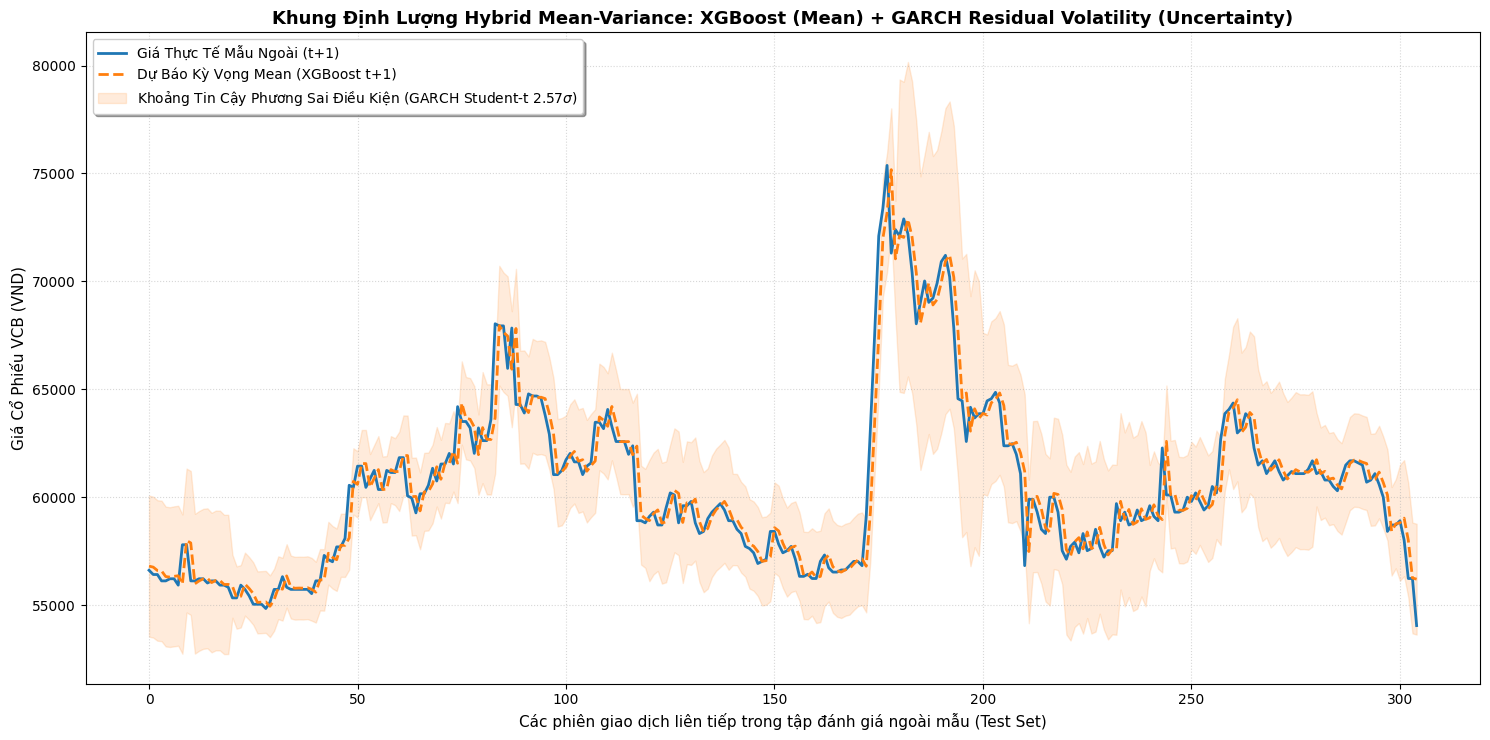

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# =====================================================================
# 1. TẢI DỮ LIỆU ĐÃ TÍNH TOÁN
# =====================================================================
try:
    results_df = pd.read_csv('../data/hybrid_predictions_output.csv', index_col=0, parse_dates=True)
    with open('../configs/garch_config.txt', 'r') as f:
        critical_value = float(f.read().strip())
except FileNotFoundError:
    raise FileNotFoundError("Khong tim thay ket qua tinh toan. Vui long chay file 'train_pipeline.py' truoc!")

actual_next_close = results_df['Actual_Next_Close']
predicted_next_close = results_df['Predicted_Next_Close']
bollinger_upper_pred = results_df['Bollinger_Lower'] # Theo logic mapping dải biên của bạn
bollinger_upper_pred = results_df['Bollinger_Upper']
bollinger_lower_pred = results_df['Bollinger_Lower']
y_test_eval = results_df['Actual_Return']
pred_test_returns_eval = results_df['Pred_Return']

# =====================================================================
# 2. ĐÁNH GIÁ ĐA CHỈ SỐ CAO CẤP & BASELINE KIỂM ĐỊNH
# =====================================================================
mae = mean_absolute_error(actual_next_close, predicted_next_close)
rmse = np.sqrt(mean_squared_error(actual_next_close, predicted_next_close))
mape = mean_absolute_percentage_error(actual_next_close, predicted_next_close) * 100

# Thước đo hướng đi (Directional Accuracy)
actual_direction = np.sign(y_test_eval.values)
pred_direction = np.sign(pred_test_returns_eval.values)
valid_dir = actual_direction != 0

directional_accuracy = np.mean(actual_direction[valid_dir] == pred_direction[valid_dir]) * 100
always_up_accuracy = np.mean(actual_direction[valid_dir] == 1) * 100
always_down_accuracy = np.mean(actual_direction[valid_dir] == -1) * 100
coverage = np.mean((actual_next_close >= bollinger_lower_pred) & (actual_next_close <= bollinger_upper_pred)) * 100

print("\n================== BÁO CÁO KIỂM ĐỊNH MÔ HÌNH TOÀN DIỆN ==================")
print(f"MAE  (Sai số tuyệt đối trung bình giá Close)  : {mae:,.2f} VND")
print(f"RMSE (Sai số căn bậc hai trung bình giá Close): {rmse:,.2f} VND")
print(f"MAPE (Sai số phần trăm trung bình giá Close)  : {mape:.2f}%")
print("-------------------------------------------------------------------------")
print(f"MÔ HÌNH: Directional Accuracy (Đoán trúng hướng) : {directional_accuracy:.2f}%")
print(f"BASELINE 1: Always Up Accuracy (Luôn đoán TĂNG) : {always_up_accuracy:.2f}%")
print(f"BASELINE 2: Always Down Accuracy (Luôn đoán GIẢM): {always_down_accuracy:.2f}%")
print("-------------------------------------------------------------------------")
print(f"ĐỘ CHUẨN RỦI RO: GARCH 95% CI Coverage (Độ phủ dải): {coverage:.2f}%")
print("=========================================================================\n")

# =====================================================================
# 3. VẼ BIỂU ĐỒ HYBRID MEAN-VARIANCE CHUẨN LUẬN VĂN
# =====================================================================
plt.figure(figsize=(15, 7.5))
plt.plot(actual_next_close.values, label='Giá Thực Tế Mẫu Ngoài (t+1)', color='#1f77b4', linewidth=2)
plt.plot(predicted_next_close.values, label='Dự Báo Kỳ Vọng Mean (XGBoost t+1)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.fill_between(
    range(len(actual_next_close)), 
    bollinger_lower_pred.values, 
    bollinger_upper_pred.values, 
    color='#ff7f0e', alpha=0.15, 
    label=f'Khoảng Tin Cậy Phương Sai Điều Kiện (GARCH Student-t {critical_value:.2f}$\sigma$)'
)

plt.title('Khung Định Lượng Hybrid Mean-Variance: XGBoost (Mean) + GARCH Residual Volatility (Uncertainty)', fontsize=13, fontweight='bold')
plt.xlabel('Các phiên giao dịch liên tiếp trong tập đánh giá ngoài mẫu (Test Set)', fontsize=11)
plt.ylabel('Giá Cổ Phiếu VCB (VND)', fontsize=11)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()